# Interpolation

## Übungsblatt

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1

#### a) Daten einlesen und darstellen

- Lese die Daten in `sprinter.csv` ein und extrahiere die Spalten in die Variablen `x_data`, `t_data` und `v_data`.
- Stelle die zurückgelegte Strecke und die Geschwindigkeit je ein einem Diagramm als Funktion der Zeit dar. Verwende `plt.subplots` mit der Option `sharex=True`, um dafür zwei übereinanderliegende Koordinatensysteme mit gekoppelten $x$-Achsen zu erzeugen.

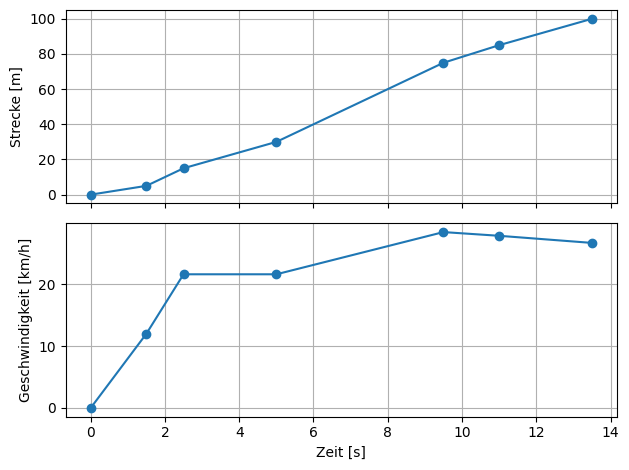

In [2]:
# Aufgabe 1 a)

sprinter_data = np.loadtxt("sprinter.csv", delimiter=",", skiprows=1)
x_data, t_data, v_data = sprinter_data.T

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t_data, x_data, "o-")
ax1.set_ylabel("Strecke [m]")
ax1.grid()
ax2.plot(t_data, v_data, "o-")
ax2.set_xlabel("Zeit [s]")
ax2.set_ylabel("Geschwindigkeit [km/h]")
ax2.grid()
plt.tight_layout()
plt.show()

#### b) Lineare Interpolation

Bestimme die linear interpolierte Geschwindigkeit zum Zeitpunt $t = 8\,\text{s}$. Füge diesen Punkt in rot ins $v$-$t$-Diagramm ein.

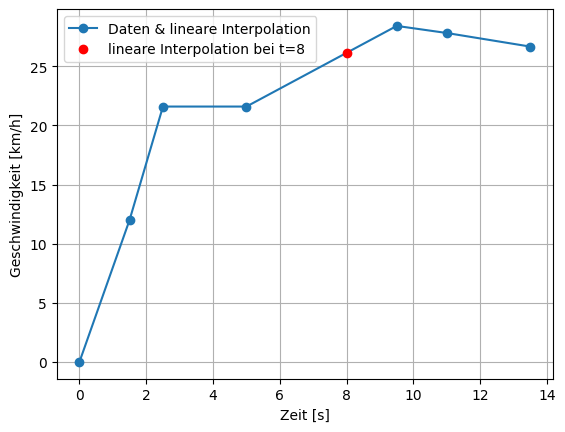

In [3]:
# Aufgabe 1 b)

t0 = 8
i = np.searchsorted(t_data, t0) - 1
m = np.diff(v_data) / np.diff(t_data)
v0 = v_data[i] + m[i] * (t0 - t_data[i])

plt.plot(t_data, v_data, "o-", label="Daten & lineare Interpolation")
plt.plot(t0, v0, "ro", label=f"lineare Interpolation bei t={t0}")
plt.xlabel("Zeit [s]")
plt.ylabel("Geschwindigkeit [km/h]")
plt.legend()
plt.grid()
plt.show()

#### c) Interpolation mit einem Polynom

- Berechne für die Geschwindigkeit als Funktion der Zeit ein Interpolationspolynom von genügend hohem Grad, so dass es exakt durch alle Datenpunkte verläuft.
- Nutze dazu die Klasse [`np.polynomial.Polynomial`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html) und deren Methode `fit`.
- Stelle das Polynom mit 200 Punkten im gleichen Zeitraum wie die Daten dar und vergleiche es mit den Datenpunkten.

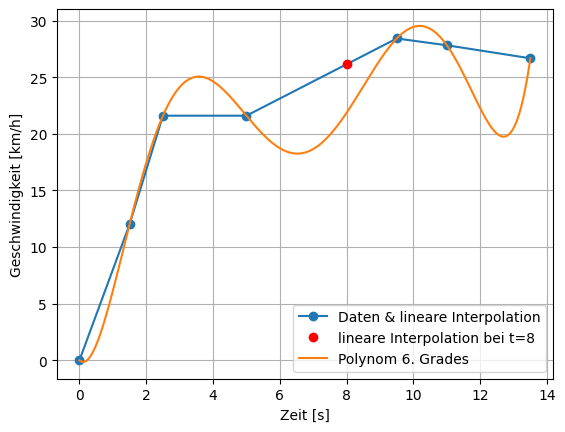

In [4]:
# Aufgabe 1.c)

deg = len(t_data) - 1
poly = np.polynomial.Polynomial.fit(t_data, v_data, deg)

t = np.linspace(t_data.min(), t_data.max(), 200)
v_poly = poly(t)

plt.plot(t_data, v_data, "o-", label="Daten & lineare Interpolation")
plt.plot(t0, v0, "ro", label=f"lineare Interpolation bei t={t0}")
plt.plot(t, v_poly, label=f"Polynom {deg}. Grades")
plt.xlabel("Zeit [s]")
plt.ylabel("Geschwindigkeit [km/h]")
plt.legend()
plt.grid()
plt.show()

#### d) Interpolation mit Cubic Spline

- Bestimme nun eine Cubic-Spline-Interpolation der Geschwindigkeit als Funktion der Zeit. Nutze dazu [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html).
- Benutze die Option `bc_type="natural"`, um natürliche Randbedingungen (*engl. boundary conditions*) zu verwenden. Was bedeutet das nochmal?
- Stelle die Interpolation zasammen mit den Daten und dem Polynom aus Teil c) grafisch dar.

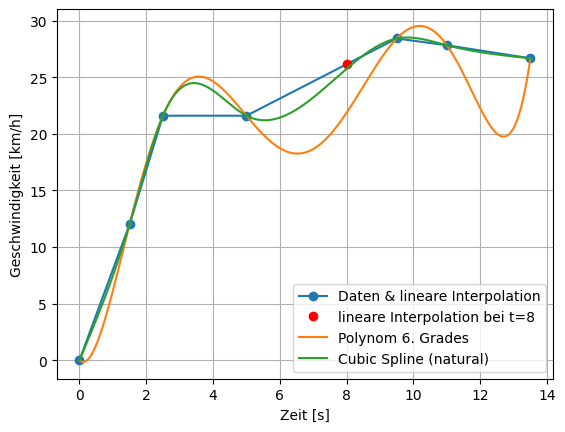

In [5]:
# Aufgabe 1.d)

from scipy.interpolate import make_interp_spline

spline = make_interp_spline(t_data, v_data, bc_type="natural")
v_spl = spline(t)

plt.plot(t_data, v_data, "o-", label="Daten & lineare Interpolation")
plt.plot(t0, v0, "ro", label=f"lineare Interpolation bei t={t0}")
plt.plot(t, v_poly, label=f"Polynom {deg}. Grades")
plt.plot(t, v_spl, label=f"Cubic Spline (natural)")
plt.xlabel("Zeit [s]")
plt.ylabel("Geschwindigkeit [km/h]")
plt.legend()
plt.grid()
plt.show()

### Aufgabe 2

#### a) Datenpunkte wählen und interpolieren

- Wähle selbst 4 Punkte in der $x$-$y$-Ebene mit ganzzahligen Koordinaten. Diese müssen in $x$-Richtung nicht zwingend den Abstand 1 und auch nicht alle den gleichen Abstand haben.
- Bestimme dazu mit SciPy die kubische Spline-Interpolation mit den drei unterschiedlichen Randbedingungen `"natural"`, `"clamped"` und `"not-a-knot"`.
- Stelle die Daten und die drei Interpolationsfunktionen grafisch dar.
- Verändere die Datenpunkte etwas, um das Verhalten der Interpolation zu untersuchen.

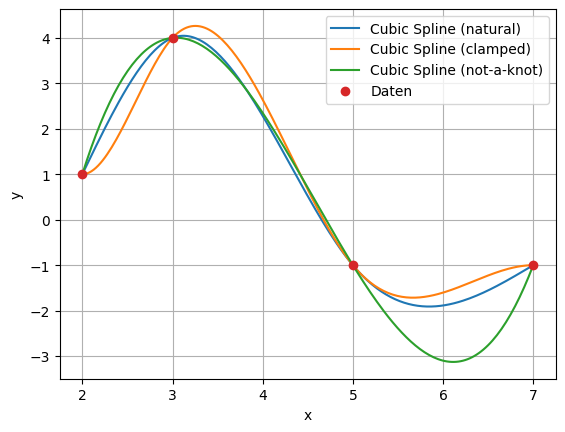

In [6]:
# Aufgabe 2.a)

x_data = np.array([2, 3, 5, 7])
y_data = np.array([1, 4, -1, -1])
x = np.linspace(x_data.min(), x_data.max(), 200)

for bc_type in ["natural", "clamped", "not-a-knot"]:
    spline = make_interp_spline(x_data, y_data, bc_type=bc_type)
    y = spline(x)
    plt.plot(x, y, label=f"Cubic Spline ({bc_type})")

plt.plot(x_data, y_data, "o", label="Daten")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

#### b) Kubischer Spline zwischen 2 Punkten von Hand berechnen

Um die Auswirkung der verschiedenen Randbedingungen noch besser zu verstehen, soll ein kubischer Spline zwischen nur zwei Punkten berechnet werden. Wir nehmen die Punkte

\begin{align*}
    (x_0, y_0) &= (1, 1) \\
    (x_1, y_1) &= (2, 0)
\end{align*}

Weil es nur zwei Punkte sind, gibt es nur ein einziges kubisches Polynom zu bestimmen, $s_0(x)$.

- Schreibe das Polynom $s_0(x)$ mit den Koeffizienten $a_0, b_0, c_0, d_0$ auf. (Der Einfachheit halber kannst du den Index 0 weglassen.)
- Bestimme die erste und zweite Ableitung von $s_0(x)$.
- Schreibe alle Bedingungen für $s_0(x)$ und deren Ableitungen auf und löse sie nach den Koeffizienten $a_0, a_1, a_2, a_3$ auf:
    1. Freier Rand: Die zweite Ableitung soll an den Randpunkten 0 sein (Natürliche Randbedingungen).
    2. Eingespannter Rand: Die erste Ableitung soll an den Randpunkten gleich 0 sein (Hermite Randbedingungen).
- Stelle schliesslich beide Fälle zusammen mit den Daten grafisch dar.
- Du kannst deine Lösung mithilfe von `make_interp_spline` überprüfen.


**b) Lösung:**

Spline Funktion und Ableitungen:

\begin{align*}
    s(x) &= a + b (x-1) + c (x-1)^2 + d (x-1)^3 \\
    s'(x) &= b + 2 c (x-1) + 3 d (x-1)^2 \\
    s''(x) &= 2 c + 6 d (x-1)
\end{align*}

Funktionswerte an den beiden Punkten:

\begin{align*}
    1 &\stackrel{!}{=} s(1) = a \\
    0 &\stackrel{!}{=} s(2) = a + b + c + d
\end{align*}

also $a = 1$ und $b + c + d = -1$.

1. Natürliche Randbedingungen (*natural*):

    \begin{align*}
        0 &\stackrel{!}{=} s''(1) = 2 c \\
        0 &\stackrel{!}{=} s''(2) = 2 c + 6 d
    \end{align*}

    Daraus folgt $c = 0$ und $d = 0$, und mit der Gleichung von oben $b = -1$. Schliesslich ist

    $$ s_\text{natural}(x) = 1 - (x-1) = 2 - x $$

2. Hermite Randbedingungen (*clamped*):

    \begin{align*}
        0 &\stackrel{!}{=} s'(1) = b \\
        0 &\stackrel{!}{=} s'(2) = b + 2 c + 3 d
    \end{align*}

    Daraus folgt $b = 0$ und es ergibt sich mit der Gleichung von oben das System

    \begin{align*}
        c + d &= -1 \\
        2 c + 3 d &= 0
    \end{align*}

    mit den Lösungen $c = -3$ und $d = 2$. Schliesslich ist

    $$ s_\text{clamped}(x) = 1 - 3 (x-1)^2 + 2 (x-1)^3 $$

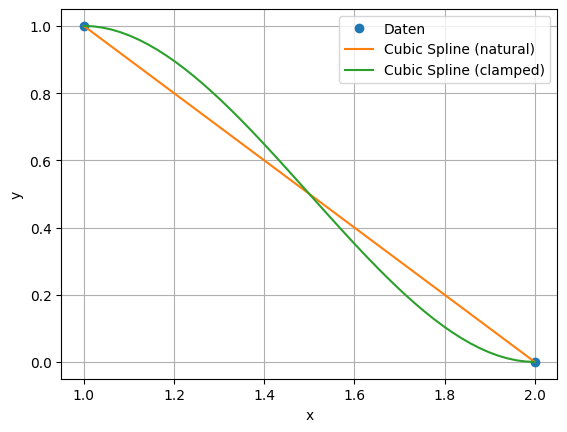

In [7]:
# Aufgabe 2.b) Darstellung der von Hand berechneten kubischen Splines

x_data = np.array([1, 2])
y_data = np.array([1, 0])
x = np.linspace(x_data.min(), x_data.max())
y_nat = 2 - x
y_clamp = 1 - 3 * (x - 1) ** 2 + 2 * (x - 1) ** 3

plt.plot(x_data, y_data, "o", label="Daten")
plt.plot(x, y_nat, label=f"Cubic Spline (natural)")
plt.plot(x, y_clamp, label=f"Cubic Spline (clamped)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

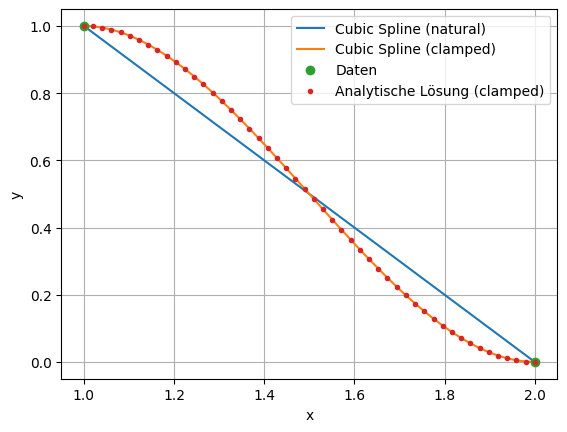

In [8]:
# Aufgabe 2.b) Darstellung der mit `make_interp_spline` berechneten kubischen Splines

x_data = np.array([1, 2])
y_data = np.array([1, 0])
x = np.linspace(x_data.min(), x_data.max())

for bc_type in ["natural", "clamped"]:
    spline = make_interp_spline(x_data, y_data, bc_type=bc_type)
    y = spline(x)
    plt.plot(x, y, label=f"Cubic Spline ({bc_type})")

plt.plot(x_data, y_data, "o", label="Daten")
plt.plot(x, y_clamp, ".", label="Analytische Lösung (clamped)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

### Aufgabe 3

#### a) Daten einlesen und darstellen

- Lese die Daten in `alter_groesse.csv` ein.
- Stelle die Grösse als Funktion des Alters grafisch dar.
- Wähle den dargestellten Bereich, so dass das Alter von 0 bis 20 Jahren und die Grösse von 80 bis 200 cm reicht.

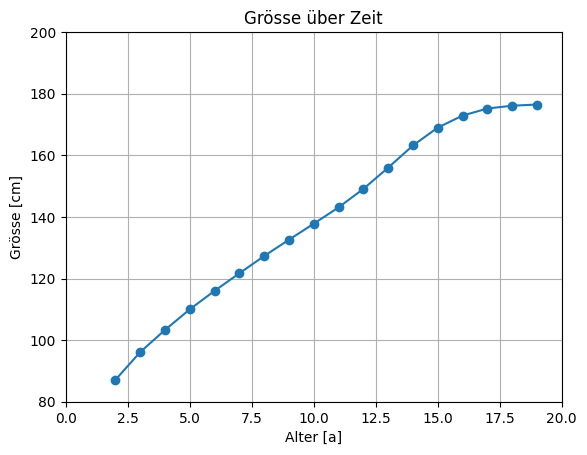

In [9]:
# Aufgabe 3.a)

age_data, size_data = np.loadtxt("alter_groesse.csv", delimiter=";", skiprows=1).T

plt.plot(age_data, size_data, "o-")
plt.xlabel("Alter [a]")
plt.ylabel("Grösse [cm]")
plt.title("Grösse über Zeit")
plt.xlim(0, 20)
plt.ylim(80, 200)
plt.grid()
plt.show()

#### b) Lineare Interpolation

Bestimme die Körpergrösse beim Alter 12.5 Jahre mithilfe der linearen Interpolation und füge diesen Punkt in das Diagramm ein.

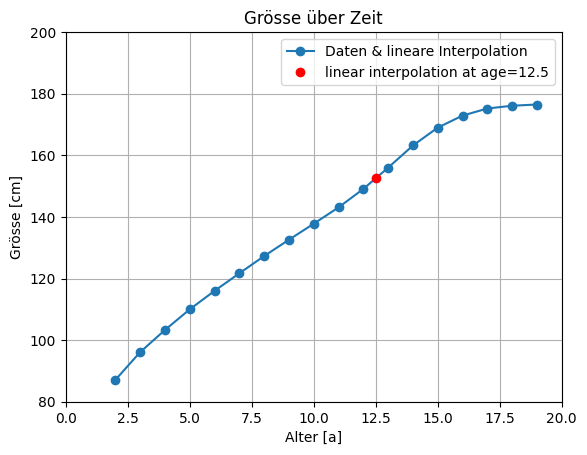

In [10]:
# Aufgabe 3.b)

age0 = 12.5

i = np.searchsorted(age_data, age0) - 1
m = np.diff(size_data) / np.diff(age_data)
size0 = size_data[i] + m[i] * (age0 - age_data[i])

plt.plot(age_data, size_data, "o-", label="Daten & lineare Interpolation")
plt.plot(age0, size0, "ro", label=f"linear interpolation at age={age0}")
plt.xlabel("Alter [a]")
plt.ylabel("Grösse [cm]")
plt.title("Grösse über Zeit")
plt.xlim(0, 20)
plt.ylim(80, 200)
plt.legend()
plt.grid()
plt.show()

#### c) Interpolationspolynom

- Bestimme zwei Interpolationspolynome:
  - `poly2` soll nur jeden zweiten Datenpunkt verwenden.
  - `poly3` soll nur jeden dritten Datenpunkt verwenden.
- Benutze dazu die Methode `fit` der Klasse `np.polynomial.Polynomial` und wähle den Grad der beiden Polynome, so dass sie exakt alle verwendeten Datenpunkte interpolieren.
- Stelle die beiden Polynome im Zeitraum $[0,20]$ dar und vergleiche mit den Datenpunkten.

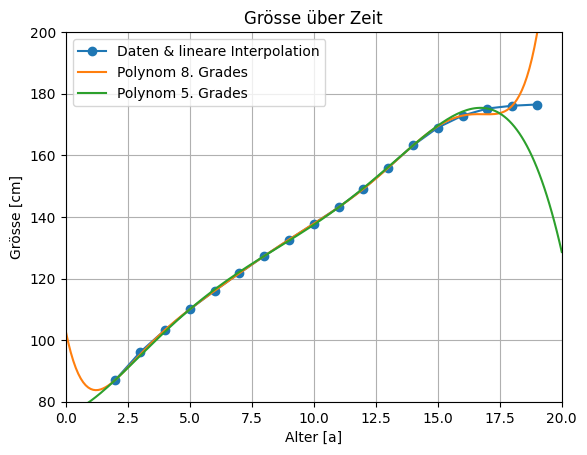

In [11]:
# Aufgabe 3.c)

poly2 = np.polynomial.Polynomial.fit(
    age_data[::2],
    size_data[::2],
    len(size_data[::2]) - 1,
)
poly3 = np.polynomial.Polynomial.fit(
    age_data[::3],
    size_data[::3],
    len(size_data[::3]) - 1,
)
age = np.linspace(0, 20, 200)
size_poly2 = poly2(age)
size_poly3 = poly3(age)

plt.plot(age_data, size_data, "o-", label="Daten & lineare Interpolation")
plt.plot(age, size_poly2, label=f"Polynom {len(size_data[::2])-1}. Grades")
plt.plot(age, size_poly3, label=f"Polynom {len(size_data[::3])-1}. Grades")
plt.xlabel("Alter [a]")
plt.ylabel("Grösse [cm]")
plt.title("Grösse über Zeit")
plt.xlim(0, 20)
plt.ylim(80, 200)
plt.legend()
plt.grid()
plt.show()

#### d) Interpolation mit Splines

- Bestimme einerseits eine lineare und andererseits eine kubische Spline-Interpolation der Grösse als Funktion des Alters. Nutze dazu [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html).
- Erstelle ein Diagramm mit zwei übereinanderliegenden Koordinatensystemen, in denen oben die beiden Interpolationsfunktionen mit den Daten verglichen werden und unten die Differenz zwischen den beiden Interpolationsfunktionen dargestellt wird.
- Wähle für die Darstellung den Bereich, in dem es Daten gibt.

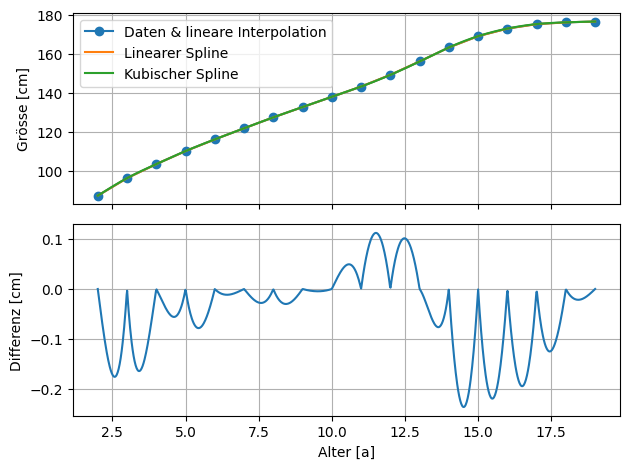

In [12]:
# Aufgabe 3.d)

spline1 = make_interp_spline(age_data, size_data, k=1)
spline3 = make_interp_spline(age_data, size_data, k=3, bc_type="natural")
age = np.linspace(age_data.min(), age_data.max(), 1000)
size_spl1 = spline1(age)
size_spl3 = spline3(age)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(age_data, size_data, "o-", label="Daten & lineare Interpolation")
ax1.plot(age, size_spl1, label=f"Linearer Spline")
ax1.plot(age, size_spl3, label=f"Kubischer Spline")
ax1.set_ylabel("Grösse [cm]")
# ax1.set_xlim(0, 20)
# ax1.set_ylim(60, 200)
ax1.legend()
ax1.grid()

ax2.plot(age, size_spl1 - size_spl3, label="Differenz")
ax2.set_xlabel("Alter [a]")
ax2.set_ylabel("Differenz [cm]")
# ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()